In [1]:
import pandas as pd
import sqlite3

sales = pd.read_csv("../data/cleaned/bm_sales_cleaned.csv")

conn = sqlite3.connect("../data/retail_sales.db")
sales.to_sql("sales", conn, if_exists="replace", index=False)

print(f"Loaded {len(sales):,} rows")
print(sales.columns.tolist())

Loaded 641,798 rows
['date', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'net_sales', 'year', 'month', 'month_name', 'day_of_week']


In [2]:
query = """
SELECT
    COUNT(*) AS sales_rows,
    ROUND(SUM(total_value), 2) AS total_sales_value,
    SUM(quantity) AS units_sold,
    ROUND(AVG(total_value), 2) AS average_sales_row_value
FROM sales;
"""

summary = pd.read_sql_query(query, conn)
summary

,sales_rows,total_sales_value,units_sold,average_sales_row_value
0,641798,73209782.99,1677123,114.07


In [3]:
monthly = pd.read_sql_query("""
SELECT strftime('%Y-%m', date) AS month,
       ROUND(SUM(total_value), 2) AS sales
FROM sales
GROUP BY month
ORDER BY month
""", conn)

monthly

,month,sales
0,2021-01,10181984.19
1,2021-02,8868663.73
2,2021-03,5483773.68
3,2021-04,6041950.50
4,2021-05,6366602.66
5,2021-06,5662290.48
6,2021-07,7643443.57
7,2021-08,7713311.72
8,2021-09,3734487.38
9,2021-10,3956906.07


In [4]:
pd.read_sql_query("""
SELECT store_id, ROUND(SUM(total_value), 2) AS sales
FROM sales
GROUP BY store_id
ORDER BY sales DESC
LIMIT 5
""", conn)

,store_id,sales
0,41,1500094.91
1,11,1495245.74
2,49,1494703.15
3,44,1493356.50
4,4,1492536.75


In [5]:
pd.read_sql_query("""
SELECT sku_id, ROUND(SUM(total_value), 2) AS sales
FROM sales
GROUP BY sku_id
ORDER BY sales DESC
LIMIT 5
""", conn)

,sku_id,sales
0,1035,1968289.04
1,1072,1882741.67
2,1174,1851457.18
3,1199,1788582.29
4,1019,1592031.54


In [6]:
pd.read_sql_query("""
SELECT channel, ROUND(SUM(total_value), 2) AS sales
FROM sales
GROUP BY channel
ORDER BY sales DESC
""", conn)

,channel,sales
0,Store,30227603.54
1,Website,20299836.60
2,MobileApp,13097435.70
3,Amazon.ae,6470717.92
4,Noon,3114189.23


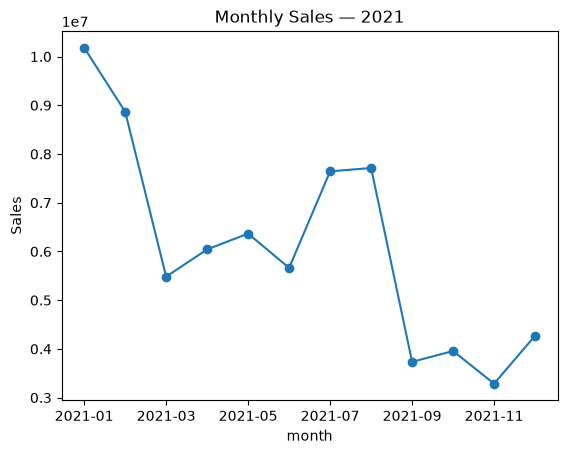

In [7]:
monthly.plot(x="month", y="sales", marker="o",
             title="Monthly Sales — 2021", ylabel="Sales", legend=False);

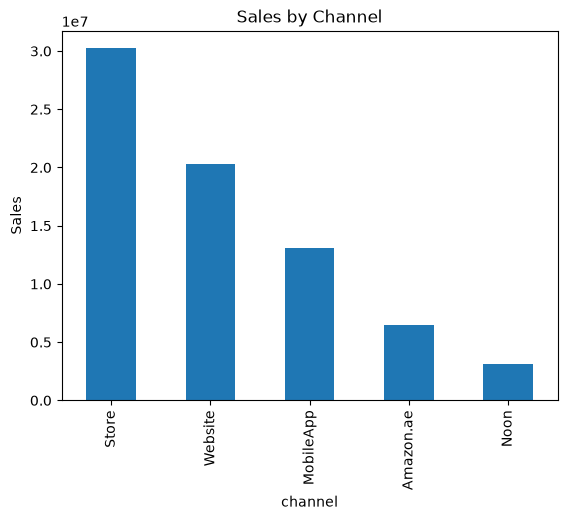

In [8]:
channels = pd.read_sql_query("""
SELECT channel, SUM(total_value) AS sales
FROM sales
GROUP BY channel
ORDER BY sales DESC
""", conn)

channels.plot.bar(x="channel", y="sales",
                  title="Sales by Channel", ylabel="Sales", legend=False);

## Key Findings

- Total sales value was 73.21 million across 641,798 sales records.
- January had the highest sales (10.18 million); November had the lowest (3.29 million).
- Stores generated 41.3% of total sales, followed by the website at 27.7%.
- Store 41 had the highest sales among stores (1.50 million).
- Product SKU 1035 had the highest sales among products (1.97 million).

These results describe the cleaned dataset. Further analysis is needed to explain the differences.